In [ ]:
# # terminal de instalação
# !pip install numpy
# !pip install python-magic-bin
# !pip uninstall matplotlib seaborn -y
# !pip install matplotlib seaborn
# !pip install --upgrade pip
# !pip install ninja
# !pip install matplotlib --force-reinstall --no-binary :all:
# !pip install seaborn
# !pip install meson
# !pip uninstall matplotlib seaborn -y
# !pip install matplotlib seaborn
# !pip install pandas
# !pip install ibge
# !pip install sidrapy
# !pip install scikit-learn
# !pip install neuralforecast
# !pip freeze > requirements.txt
# !pyenv install 3.11.6
# !pyenv global 3.11.6
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install xgboost




# Requeiments

In [1]:
import os
import sys
import pandas as pd
import seaborn as sn
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
import sidrapy
from ibge.localidades import *
# import torch
from datetime import datetime

# Importando os dados da base WSUS

### Documentação das variáveis


### Variaveis identificadas na documentação

- TP_NOT: Tipo de Notificação [varchar(1)] # Valor Constante

        1 – Negativa

        2 – Individual

        3 – Surto

        4 – Agregado 

- TP_NOT.1: Tipo de Notificação  - 2 - Individual [varchar(1)] # Valor Constante

- ID_AGRAVO: Identificação de Agravo/Doença (CID) [varchar2(4)] # Valor Constante

- DT_NOTIFIC: Data da Notificação [date] # Ano mais importante

- NU_ANO: Ano da Notificação [varchar(4)]

- SG_UF_NOT: SG ? UF do Estado de Notificação [varchar(2)]

- ID_MUNICIP: Id de identificação do Municipio [varchar(6)]

- ID_REGIONA: Código da regional de saúde da tabela de município do sistema [varchar2(4)]

- ID_UNIDADE: Códigos e nomes de estabelecimento [varchar(7)] # sem necessidade

- DT_DIAG: Data do inicio do tratamento [date]

- SEM_DIAG: Semana epidemiológica do diagnóstico do caso notificado [varchar(6)]

- ANO_NASC: Ano de Nascimento [date]

- NU_IDADE_N: Idade, com Código (4 - Ano e 0 para completar) A composição da variável obedece o seguinte critério: 1° dígito: Ex: 3009 – nove meses, 4018 – dezoito anos  [number(4)]

        1. Hora

        2. Dia

        3. Mês

        4. Ano
        
- CS_SEXO: Sexo [varchar(1)]

        0. Masculino

        1. Feminino

- CS_GESTANT: Código Gestante [varchar2(1)] # Não usar
        1. 1ºTrimestre 

        2. 2ºTrimestre 

        3. 3ºTrimestre

        4. Idade gestacional Ignorada 

        5. Não 

        6. Não se aplica

        9. Ignorado
        
- CS_RACA: Código Raça [varchar2(1)]

        1. Branca 

        2. Preta 

        3. Amarela

        4. Parda 

        5. Indígena 

        9. Ignorado

- CS_ESCOL_N: Código Escolaridade [varchar2(2)]

        0. Analfabeto 

        1. 1ª a 4ª série incompleta do EF (antigo primário ou 1º grau) 

        2. 4ª série completa do EF (antigo primário ou 1º grau)

        3. 5ª à 8ª série incompleta do EF (antigo ginásio ou 1º grau) 

        4. Ensino fundamental completo (antigo ginásio ou 1º grau) 

        5. Ensino médio incompleto (antigo colegial ou 2º grau )

        6. Ensino médio completo (antigo colegial ou 2º grau ) 

        7. Educação superior incompleta 

        8. Educação superior completa 

        9. Ignorado 

        10. Não se aplica

- SG_UF: Código do Estado Notificante  [varchar(2)]

- ID_MN_RESI: Código do município de residência do caso notificado  [varchar2(6)]

- ID_RG_RESI: Regional de saúde onde está localizado o município de residência do paciente por ocasião da notificação [varchar2(4)]

- ID_PAIS: País onde residia o paciente por ocasião da notificação  [varchar(4)]

- NDUPLIC_N: Identifica duplicidade  [varchar2(1)]

        0 ou branco – Não identificado

        1 – Não é duplicidade (nãolistar)

        2 – Duplicidade (não contar) 

- DT_DIGITA: Data de digitação [date]

- DT_TRANSUS: Data de transferência da unidade de saúde [date]

- DT_TRANSDM: Data de transferência do distrito municipal [date]

- DT_TRANSSM: Data de transferência da secretaria municipal de saúde [date]

- DT_TRANSRM: Data de transferência da regional municipal [date] # Valor Constante

- DT_TRANSRS: Data de transferência da regional de saúde [date]

- DT_TRANSSE: Data de transferência da secretaria estadual de saúde [date]

- NU_LOTE_V: Identifica o Lote da transferência da notificação um nível do sistema para outro

- NU_LOTE_H: Identifica do Lote da transferência de registros dentro de um mesmo nível do sistema

- CS_FLXRET: Identifica se o registro está habilitado ou foi enviado pelo fluxo de retorno para o município de residência # Valor Constante

        0 - Não

        1 - habilitado para envio.

        2 - enviado 

- FLXRECEBI: Identifica se o registro foi recebido pelo fluxo de retorno [varchar2(1)] # Valor Constante

- MIGRADO_W: Identifica se o registro é oriundo da rotina de migração da base Windows. [varchar2(1)]

        1. migrado do Sinan Windows 

- ID_OCUPA_N: Ocupação do indivíduo que sofreu o agravo [varchar2(6)]

- NU_LESOES:  Nº de lesões cutâneas [numeric(2)]

- FORMACLINI: [varchar(1)] 

        1- I -Indeterminada

        2- T - Tuberculóide

        3- D - Dimorfa

        4- V - Virchowiana

        5- Não classificado

- AVALIA_N: Avaliação do Grau de Incapacidade Física no Diagnóstico [varchar(1)]

        0 Grau zero

        1- Grau I

        2- Grau II

        3 - Não avaliado

- CLASSOPERA: Classificação operacional, por ocasião do diagnóstico, para eleição do esquema terapêutico [varchar(1)]

        1- PB - Paucibacilar

        2- MB - Multibacilar

- MODOENTR: Modo de entrada do paciente no sistema [varchar(1)]

        1- Caso novo

        2- Transferencia do mesmo município (outra unidade)

        3- Transferência de outro município (mesma UF)

        4- Transferência de outro estado

        5- Transferencia de outro país

        6- Recidiva

        7- Outros reingressos

        9- Ignorado

- MODODETECT: Modo de detecção do caso novo [varchar(1)]

        1- Encaminhamento

        2- Demanda espontânea

        3- Exame de coletividade

        4- Exame de contatos

        5- Outros modos

        9- Ignorado

- BACILOSCOP: Informar o resultado da baciloscopia [varchar(1)]

        1. Positiva

        2. Negativa

        3. Não realizada

        9. Ignorado

- DTINICTRAT: Data do inicio do tratamento [date]

- ESQ_INI_N: Esquema terapêutico instituído por ocasião do diagnostico [varchar(1)]

        1. PQT/ PB/ 6 doses

        2. PQT/ MB/ 12 doses

        3. Outros Esquemas Substitutos

- CONTREG: Número de pessoas que residam ou tenham residido, nos últimos 5 anos com o doente, a contar da Data do diagnóstico [numeric(2)]

- NERVOSAFET: Número de nervos afetados [numeric(2)]

- UFATUAL : Código da UF do cadastro do IBGE [varchar(2)] # Valor Constante

- ID_MUNI_AT :Código e nome dos municípios do cadastro do IBGE [varchar(6)]

- DT_NOTI_AT: Data de notificação atual [date]

- ID_UNID_AT: Códigos e nomes de estabelecimentos de saúde (CNES) [varchar(7)]

- UFRESAT: Sigla da UF de residência atual do paciente [varchar(2)]

- MUNIRESAT: código IBGE do município de residência atual do paciente [varchar(6)]

- DTULTCOMP: Data do último comparecimento [date]

- CLASSATUAL: Classificação operacional atual [varchar(1)]

        1. PB (Paucibacilar) 

        2. MB (Multibacilar) 

- AVAL_ATU_N: Avaliação de incapacidade física no momento da cura - [varchar(1)]

        0. grau zero

        1. grau I

        2. grau II

        3. Não avaliado

        9- Ignorado

- ESQ_ATU_N: Esquema terapêutico em uso [varchar(1)]

        1- PQT/PB/06 doses

        2- PQT/MB/12 doses

        3- Outros Esquemas Substitutivos

- DOSE_RECEB: Número de doses supervisionadas [numeric(2)]

- EPIS_RACIO: Episódio Reacional Durante o Tratamento [varchar(1)]

        1- Reação tipo 1

        2- Reação tipo 2

        3- Reação tipo 1 e 2

- DTMUDESQ:  Data de mudança do Esquema [date]

- CONTEXAM: Número de contatos examinados [numeric(2)]

- DTALTA_N: Data da alta [date]

- TPALTA_N: Tipo de Saída [varchar(1)]

        1- Cura

        2- transf. p/ mesmo município

        3- transf. p/ outro município

        4- transf. p/ outro Estado

        5- transf. p/ outro país

        6- Óbito

        7- Abandono

        8- Erro diagnóstico

        9- transf. não especificada

- IN_VINCULA: Vinculação [varchar(1)]

        0 - Não Vinculada

        1 - Vinculada
        
- NU_LOTE_IA: Transferência vertical da investigação e do acompanhamento [varchar(7)]

## Ativar o ambiente virtual

In [2]:
# Caminho para o ambiente virtual
venv_path = os.path.join('.', 'venv_health', 'Scripts', 'activate')  # Ajuste para Linux/Mac: 'bin/activate_this.py'

os.system(venv_path)

# Agora o script usará as dependências do ambiente virtual
print("Ambiente virtual ativado:", sys.prefix)

Ambiente virtual ativado: d:\python\data_health\venv_health


# Obter os dados

## Buscando os arquivos já tratados

Os dados são obtidos de um arquivo csv já tratado, caso não tenha o arquivo ele será criado automaticamente pelo script que executará ambas etapas:

- Converter o arquivo .dbc em .csv, gerando o arquivo `HANSENIASE_TOTAL_`

- Pré-processamento dos dados do Wsus¹ gerando o csv já tratado `HANSENIASE_PROCESS_`

In [3]:
print("-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------")
arquivos = []
path_csv = os.path.join('.', 'data', 'HANS')

# Garantir que o diretório existe
if not os.path.exists(path_csv):
    print(f"Diretório não encontrado: {path_csv}")
    os.makedirs(path_csv)  # Criar o diretório se não existir

# Verificar arquivos no diretório
for f in os.listdir(path_csv):
    if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
        try:
            # Extrair data do nome do arquivo
            data_str = f.split('_')[-3:]  # Pega os últimos 3 elementos (dd, mm, yyyy)
            data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
            arquivos.append((data, f))
        except Exception as e:
            print(f"Arquivo com formato inválido: {f} - {e}")

# Executar script externo se nenhum arquivo for encontrado
if not arquivos:
    print("Nenhum arquivo encontrado. Executando script para gerar arquivo...")
    path_gerar_wsus = os.path.join('.', 'gerar_wsus_csv.py')
    resultado = os.system('python ' + path_gerar_wsus)
    
    if resultado == 0:
        print("Script executado com sucesso. Verificando novo arquivo...")
        # Recarregar lista de arquivos após execução do script
        for f in os.listdir(path_csv):
            if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
                try:
                    data_str = f.split('_')[-3:]
                    data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
                    arquivos.append((data, f))
                except Exception as e:
                    print(f"Erro ao processar novo arquivo: {f} - {e}")
    else:
        print("Erro na execução do script. Arquivo não gerado.")

# Exibir lista final de arquivos encontrados
print("Arquivos encontrados:", arquivos)

if arquivos:
    # Ordenar arquivos pela data mais recente
    arquivos.sort(reverse=True, key=lambda x: x[0])
    
    # Pegar arquivo mais recente
    ultimo_arquivo = os.path.join(path_csv, arquivos[0][1])
    
    print(f"Carregando arquivo mais recente: {ultimo_arquivo}")
    
    # Carregar dados
    df_dados = pd.read_csv(ultimo_arquivo, encoding='utf-8', low_memory=False)
    
    print("\nPrimeiras linhas do DataFrame:")
    print(f"\nTotal de registros: {len(df_dados):,}")
    print(f"Data de referência: {arquivos[0][0].strftime('%d/%m/%Y')}")
else:
    print("Nenhum arquivo válido encontrado na pasta")

-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------
Arquivos encontrados: [(datetime.datetime(2025, 3, 7, 0, 0), 'HANSENIASE_PROCESS_07_03_2025.csv')]
Carregando arquivo mais recente: .\data\HANS\HANSENIASE_PROCESS_07_03_2025.csv

Primeiras linhas do DataFrame:

Total de registros: 984,035
Data de referência: 07/03/2025


# Analises Graficas

## Ocorrências de casos

### Notificações por Mês

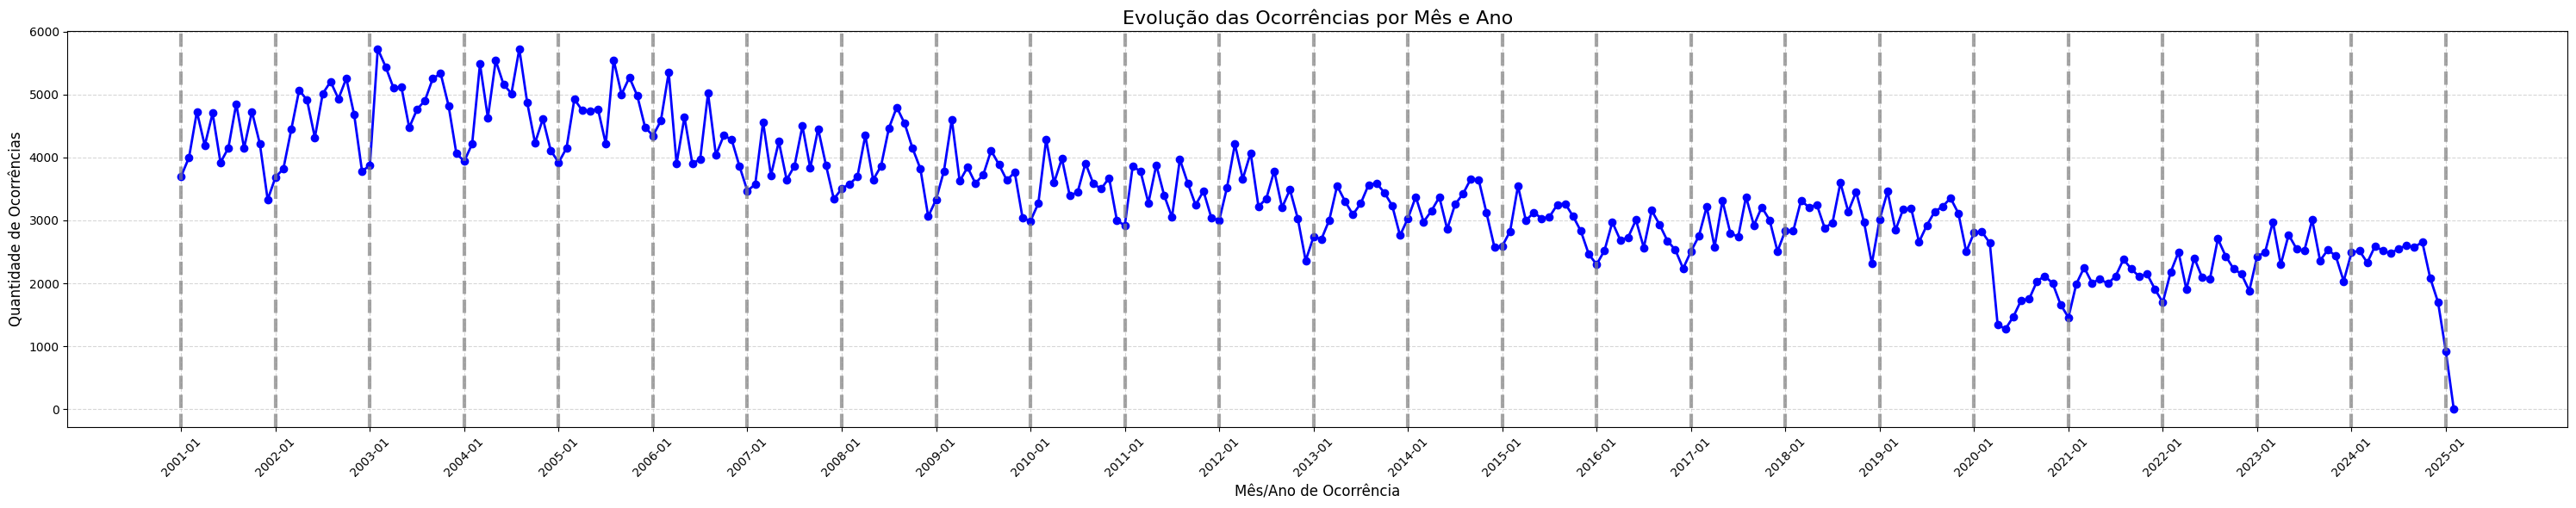

In [4]:
# Converter a coluna DT_NOTIFIC para datetime
df_dados["DT_NOTIFIC"] = pd.to_datetime(df_dados["DT_NOTIFIC"], format='%Y-%m-%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_dados["ANO_MES"] = df_dados["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("ANO_MES").size().reset_index(name="quantidade")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].str[:4]
anos_unicos = dados_agrupados["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados["ANO_MES"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados["ANO_MES"][::12]  # Seleciona a cada 6 meses
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Notificações por Ano

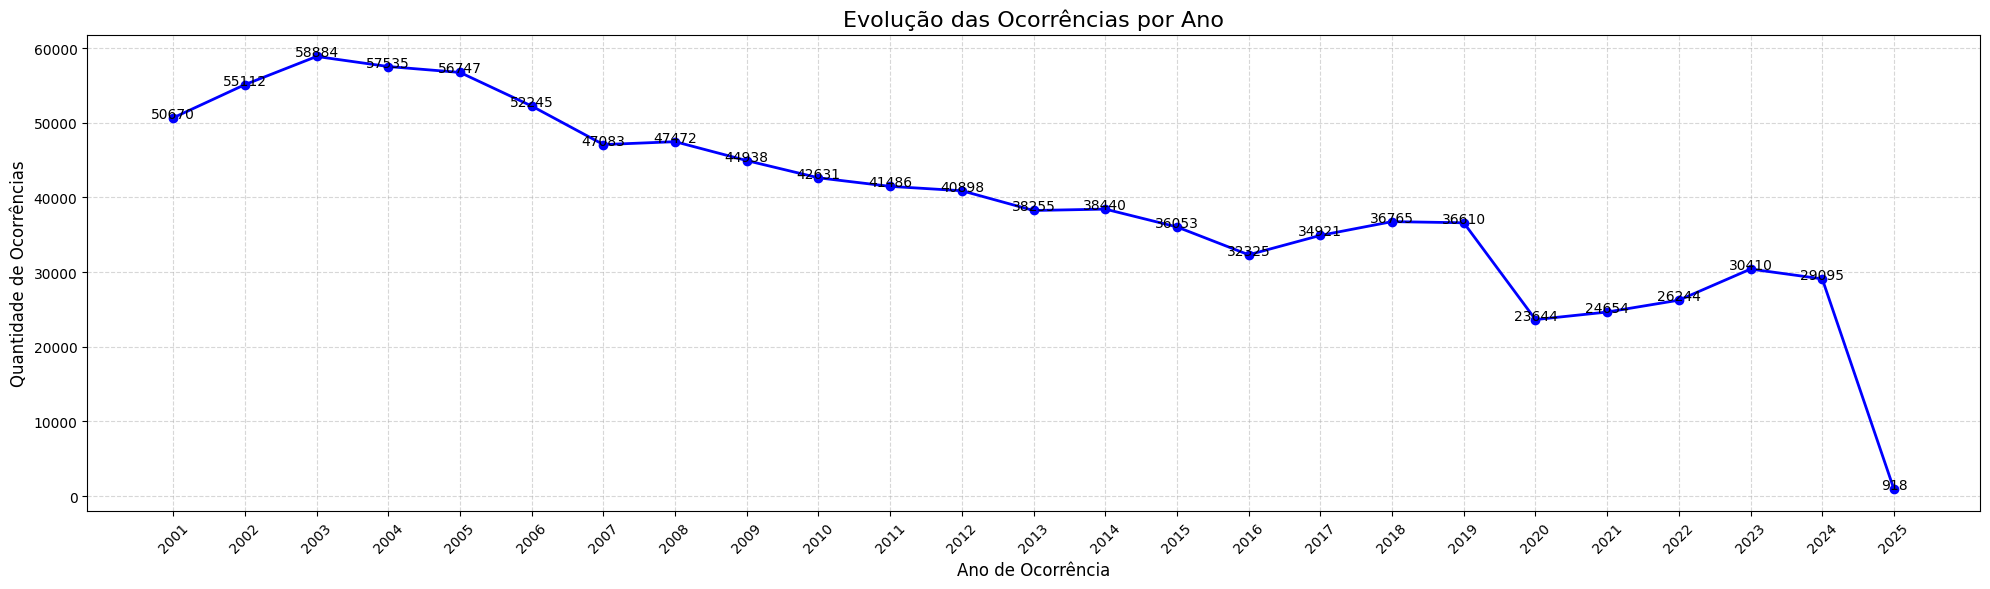

In [5]:
# Agrupar os dados por ano e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("NU_ANO").size().reset_index(name="quantidade")

# Plotar o gráfico de linha com os anos no eixo X e a quantidade no eixo Y
fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(
    dados_agrupados["NU_ANO"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Ano", fontsize=16)
ax.set_xlabel("Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Adicionar rótulos nos pontos
for i, txt in enumerate(dados_agrupados["quantidade"]):
    ax.annotate(txt, (dados_agrupados["NU_ANO"][i], dados_agrupados["quantidade"][i]), fontsize=10, ha='center')

# Melhorar a aparência do gráfico
plt.xticks(dados_agrupados["NU_ANO"], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()

### Notificação por Estado

In [6]:
# Busco as informações dos estados
dados_estados = Estados()
if isinstance(dados_estados.json_ibge, (list, dict)):
    dt_est = dados_estados.json_ibge  # Já é uma estrutura Python válida
    print(dt_est)
else:
    dt_est = json.loads(dados_estados.json_ibge)  # Caso seja uma string JSON
    print(dt_est)
dt_est[17]

[{'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 12, 'sigla': 'AC', 'nome': 'Acre', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 13, 'sigla': 'AM', 'nome': 'Amazonas', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 14, 'sigla': 'RR', 'nome': 'Roraima', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 15, 'sigla': 'PA', 'nome': 'Pará', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 16, 'sigla': 'AP', 'nome': 'Amapá', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 17, 'sigla': 'TO', 'nome': 'Tocantins', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 21, 'sigla': 'MA', 'nome': 'Maranhão', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 22, 'sigla': 'PI', 'nome': 'Piauí', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 23, 'sigla': 'CE', 'nome': 'Ceará', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 24, 'si

{'id': 32,
 'sigla': 'ES',
 'nome': 'Espírito Santo',
 'regiao': {'id': 3, 'sigla': 'SE', 'nome': 'Sudeste'}}

In [7]:
# Extraindo corretamente as informações de estado e região
dados_est = []
for dado in dt_est:
    linha = {
        "id": dado["id"],
        "sigla": dado["sigla"],
        "nome": dado["nome"],
        "regiao": dado["regiao"]["nome"]  # Acessa o nome da região corretamente
    }
    dados_est.append(linha)

# Criar DataFrame com as informações de estados e regiões
df_estados = pd.DataFrame(dados_est)  
print(df_estados.head())



   id sigla      nome regiao
0  11    RO  Rondônia  Norte
1  12    AC      Acre  Norte
2  13    AM  Amazonas  Norte
3  14    RR   Roraima  Norte
4  15    PA      Pará  Norte


### Casos por Estado (Separado por Região)

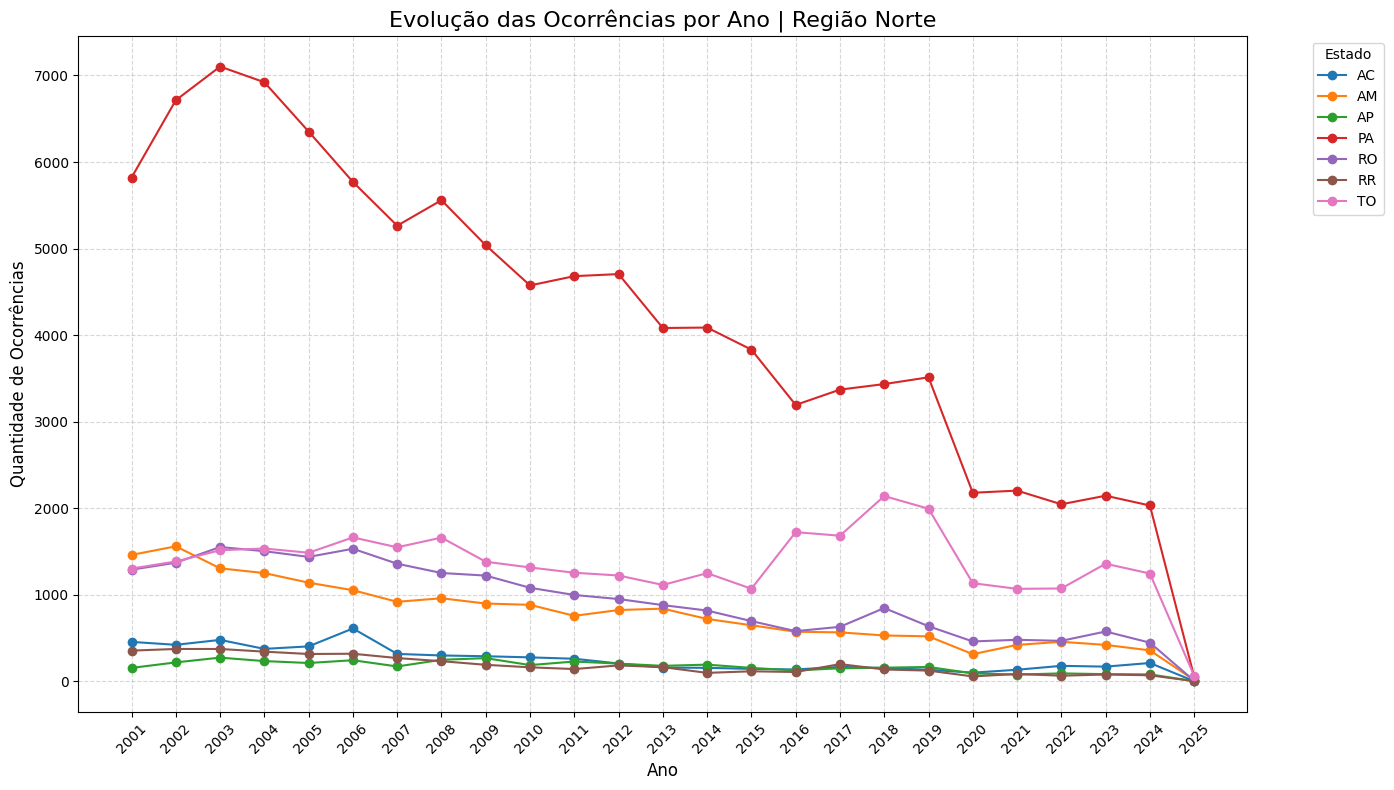

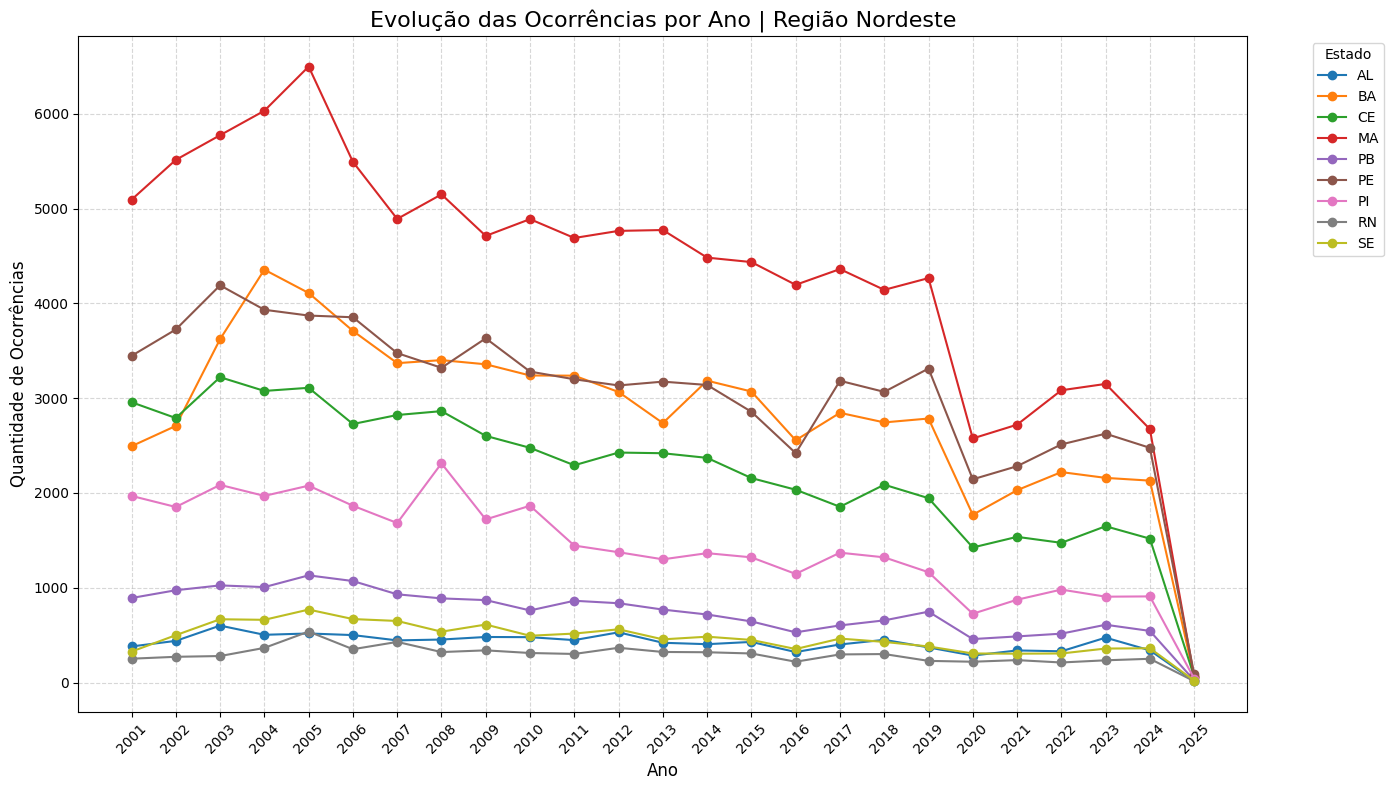

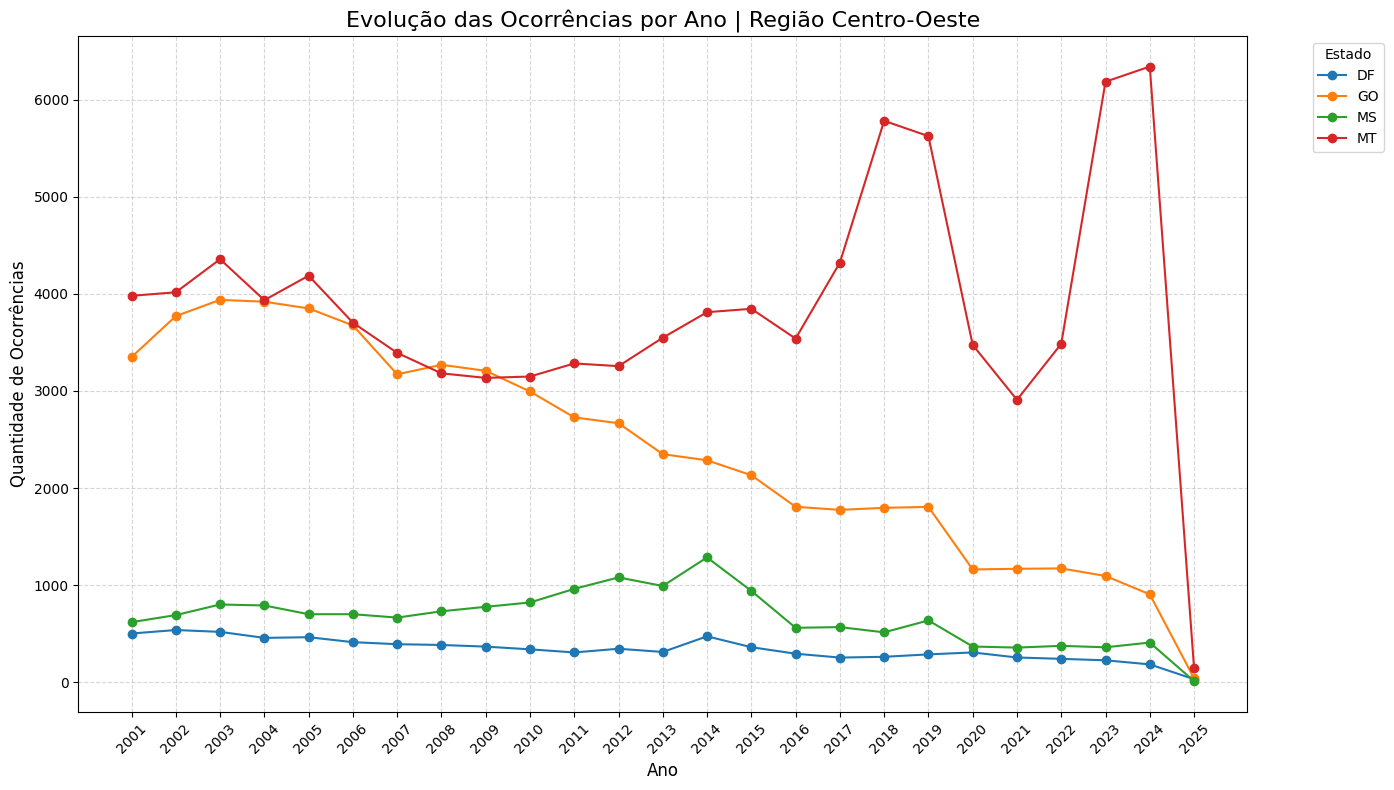

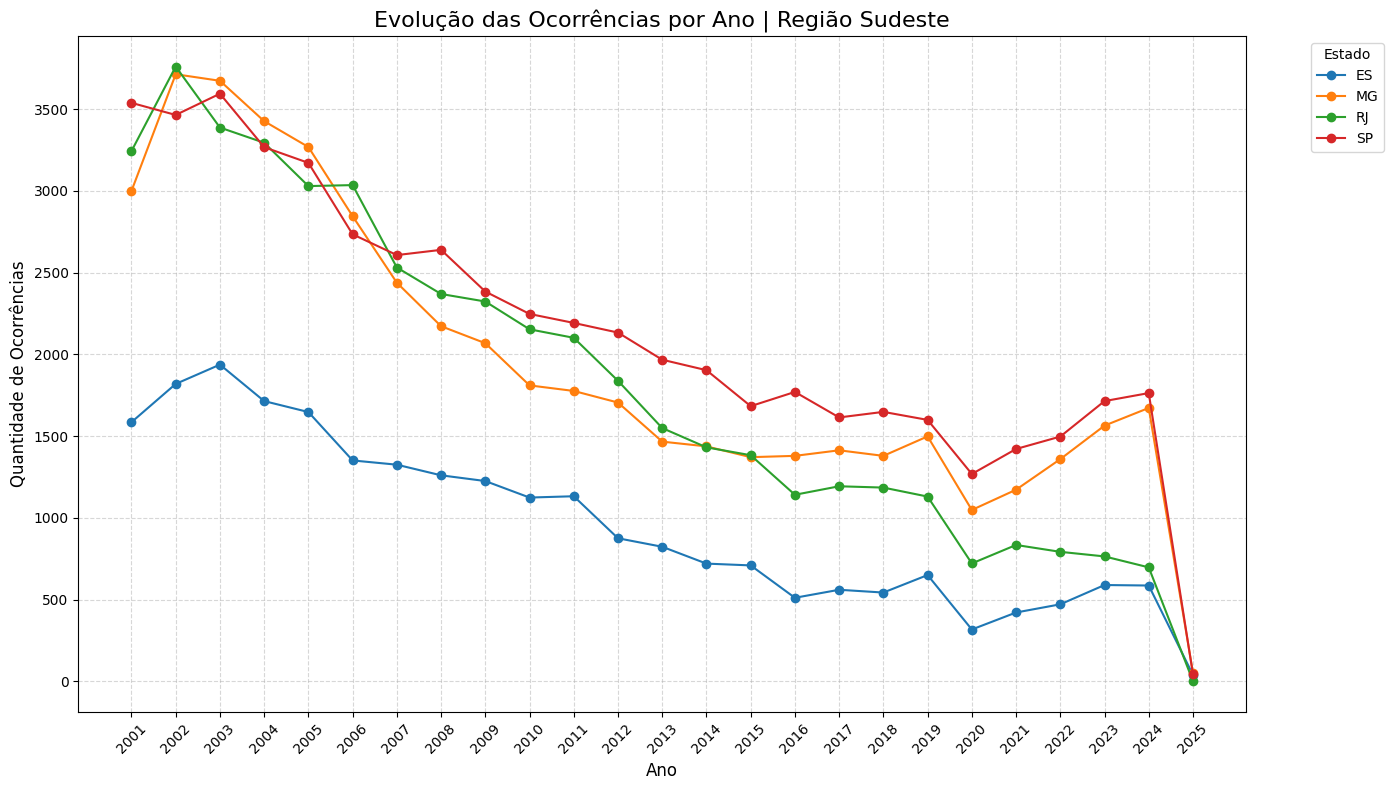

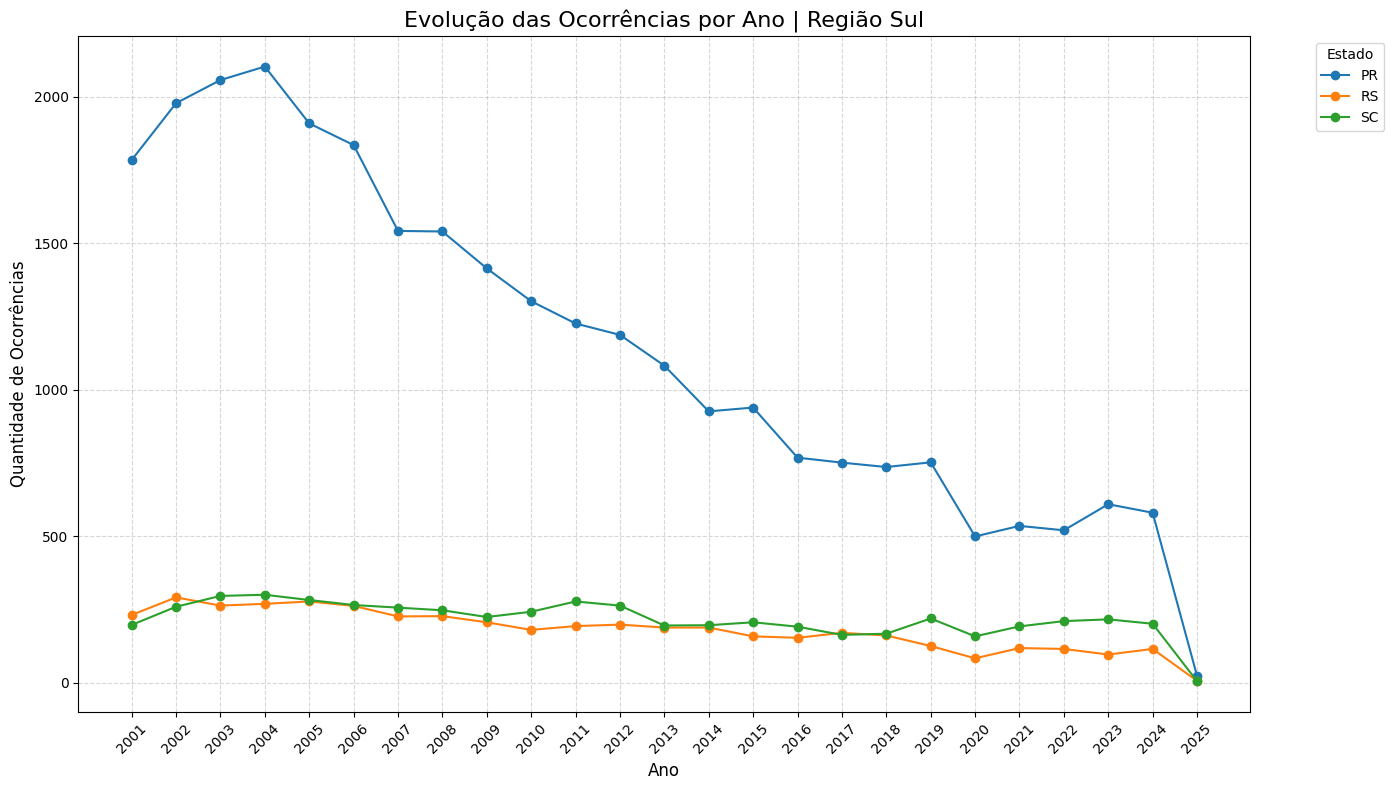

In [8]:
# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região
dados_agrupados = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 8))

    dados_regiao = dados_agrupados[dados_agrupados['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução das Ocorrências por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

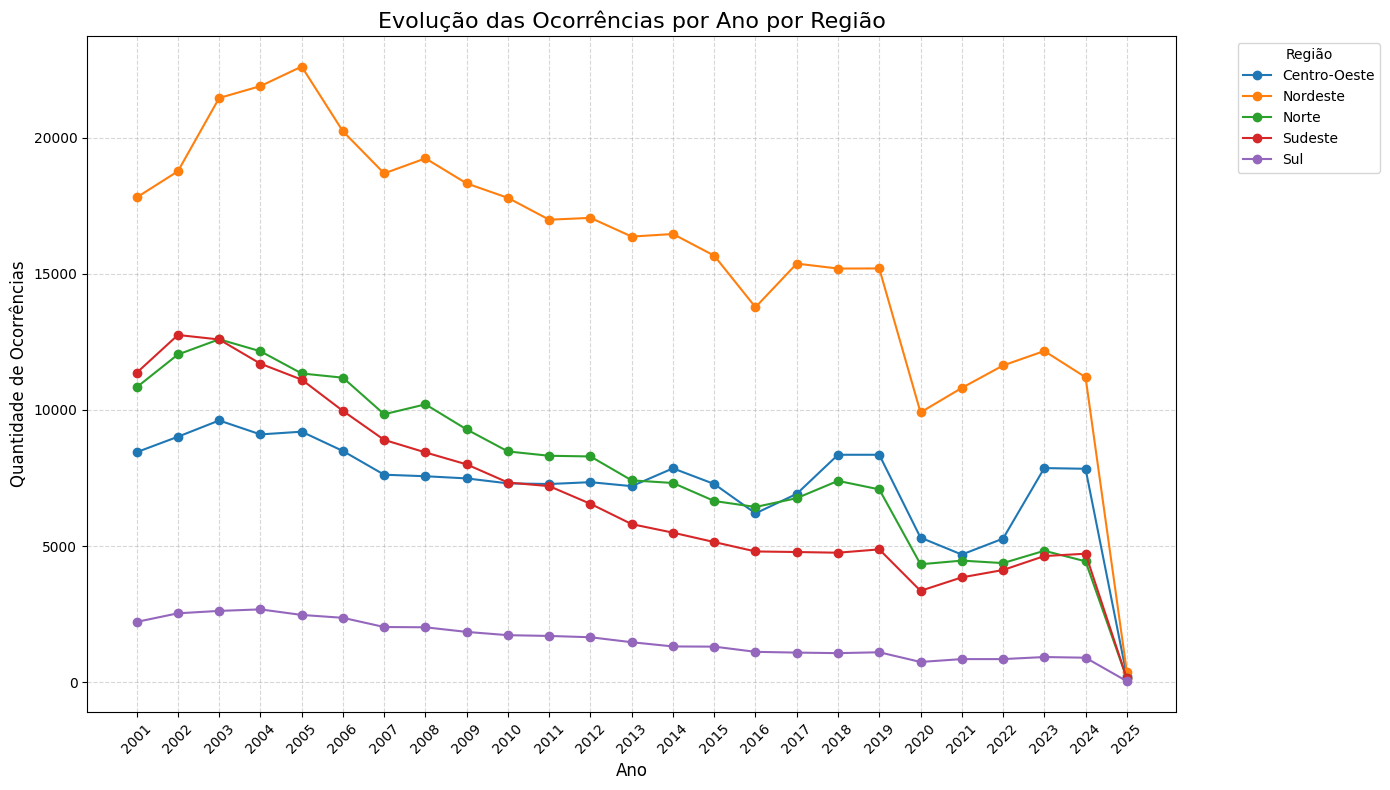

In [9]:

# Criar DataFrame de estados com regiões
df_estados = pd.DataFrame(dados_est)

# Adicionar a coluna de região ao DataFrame de dados com base no estado
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região (agora sem separar por estado)
dados_agrupados_regiao = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados_regiao['regiao'].unique()

# Criar um gráfico de linha para todos os dados por região
fig, ax = plt.subplots(figsize=(14, 8))

# Plotar as ocorrências totais para cada região ao longo dos anos
for regiao in regioes:
    dados_regiao = dados_agrupados_regiao[dados_agrupados_regiao['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade'],
        marker='o',
        label=regiao
    )

# Configurar o título e rótulos dos eixos
ax.set_title('Evolução das Ocorrências por Ano por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_regiao['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir legenda com as regiões
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()


## Mortalidade

### Por Ano

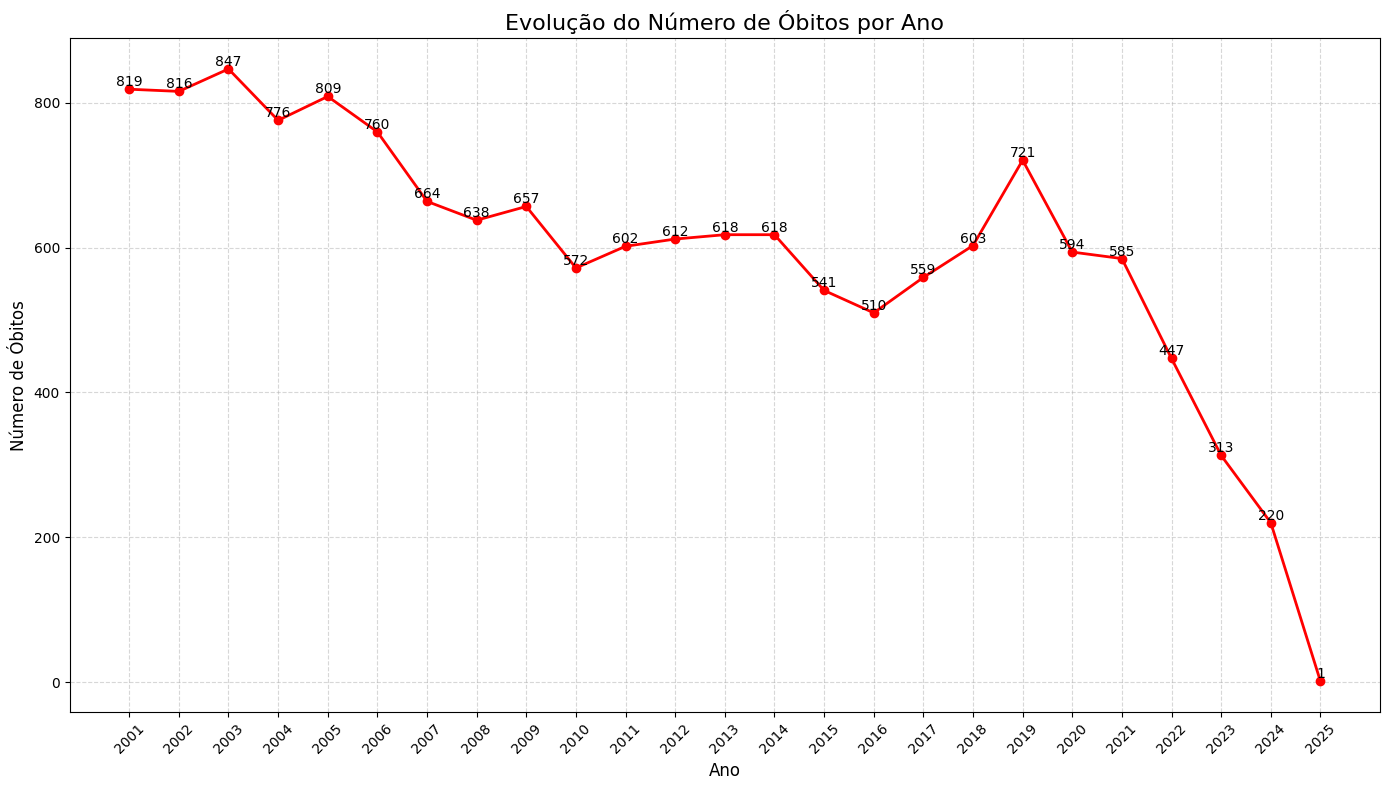

In [14]:

# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 6)
df_obitos = df_dados[df_dados['TPALTA_N'] == '6']

# Agrupar os dados por ano e contar a quantidade de óbitos
dados_agrupados_obitos = df_obitos.groupby('NU_ANO').size().reset_index(name='quantidade_obitos')

# Criar o gráfico de linha
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(
    dados_agrupados_obitos['NU_ANO'],
    dados_agrupados_obitos['quantidade_obitos'],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='r'  # Cor vermelha para óbitos
)

# Adicionar os números de óbitos nos pontos do gráfico
for i, txt in enumerate(dados_agrupados_obitos['quantidade_obitos']):
    ax.annotate(txt, (dados_agrupados_obitos['NU_ANO'][i], dados_agrupados_obitos['quantidade_obitos'][i]),
                fontsize=10, ha='center', va='bottom')

# Configurar título e rótulos dos eixos
ax.set_title('Evolução do Número de Óbitos por Ano', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Número de Óbitos', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_obitos['NU_ANO'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()


### Por Mês 

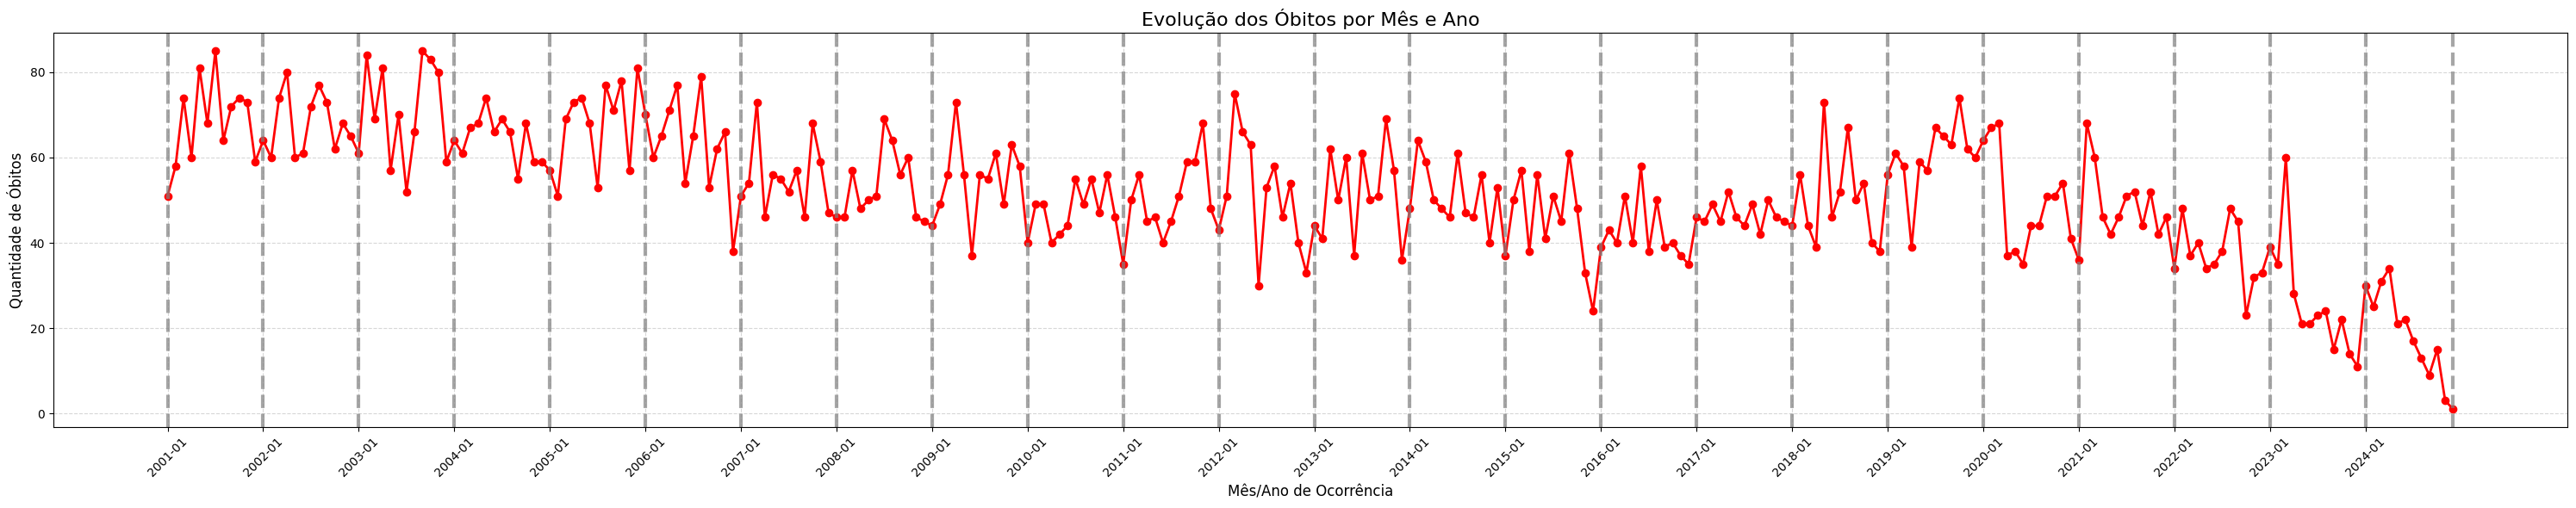

In [ ]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 6)
df_obitos = df_dados[df_dados['TPALTA_N'] == '6'].copy()

# Converter a coluna DT_NOTIFIC para datetime
df_obitos.loc[:, "DT_NOTIFIC"] = pd.to_datetime(df_obitos["DT_NOTIFIC"], format='%Y%m%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_obitos.loc[:, "ANO_MES"] = df_obitos["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de óbitos
dados_agrupados_obitos = df_obitos.groupby("ANO_MES").size().reset_index(name="quantidade_obitos")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados_obitos["ANO"] = dados_agrupados_obitos["ANO_MES"].str[:4]
anos_unicos = dados_agrupados_obitos["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados_obitos["ANO_MES"],
    dados_agrupados_obitos["quantidade_obitos"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='r'  # Cor vermelha para óbitos
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução dos Óbitos por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Óbitos", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados_obitos["ANO_MES"][::12]  # Seleciona a cada 12 meses (1 ano)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Por Estado

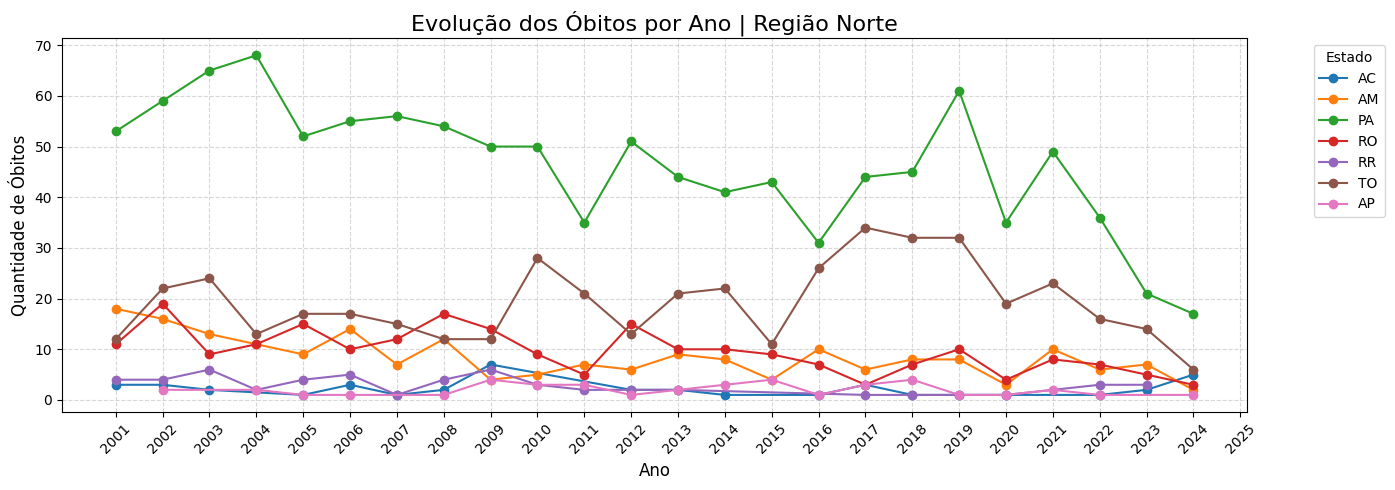

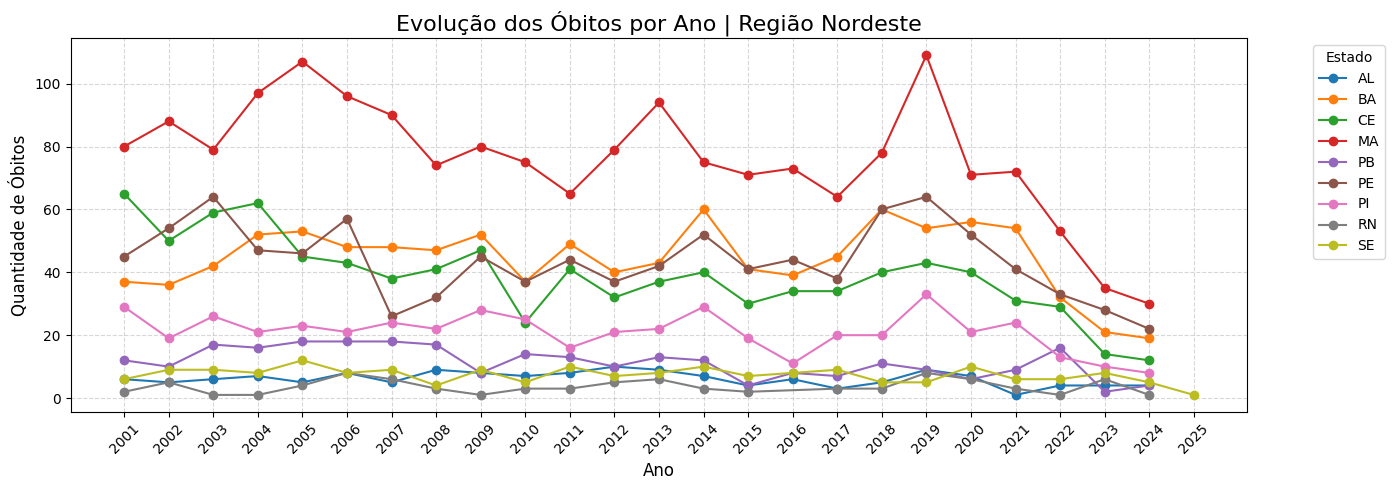

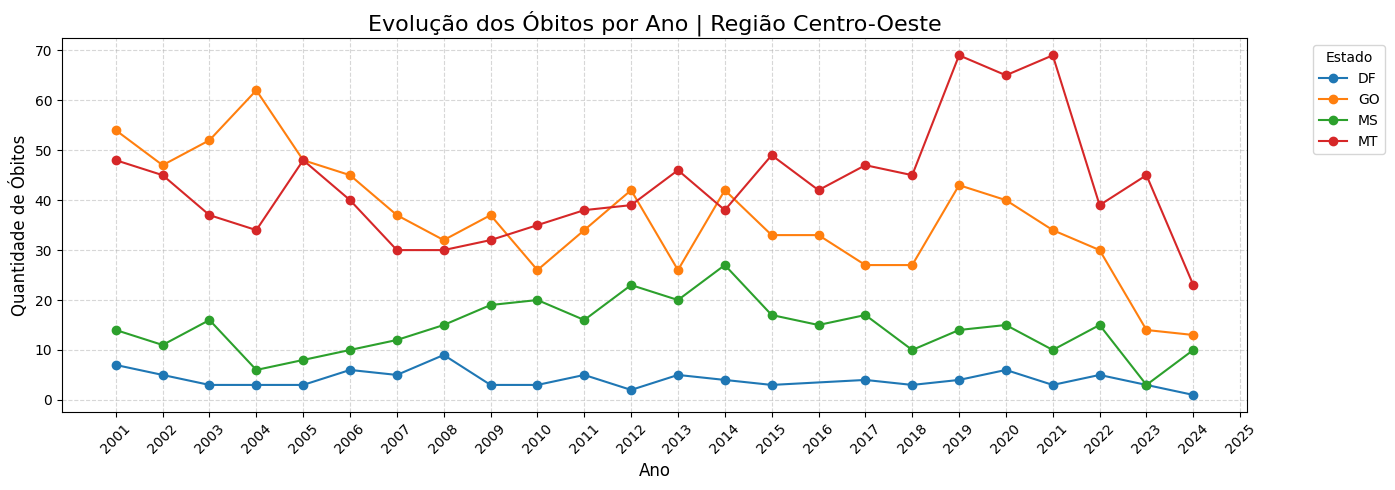

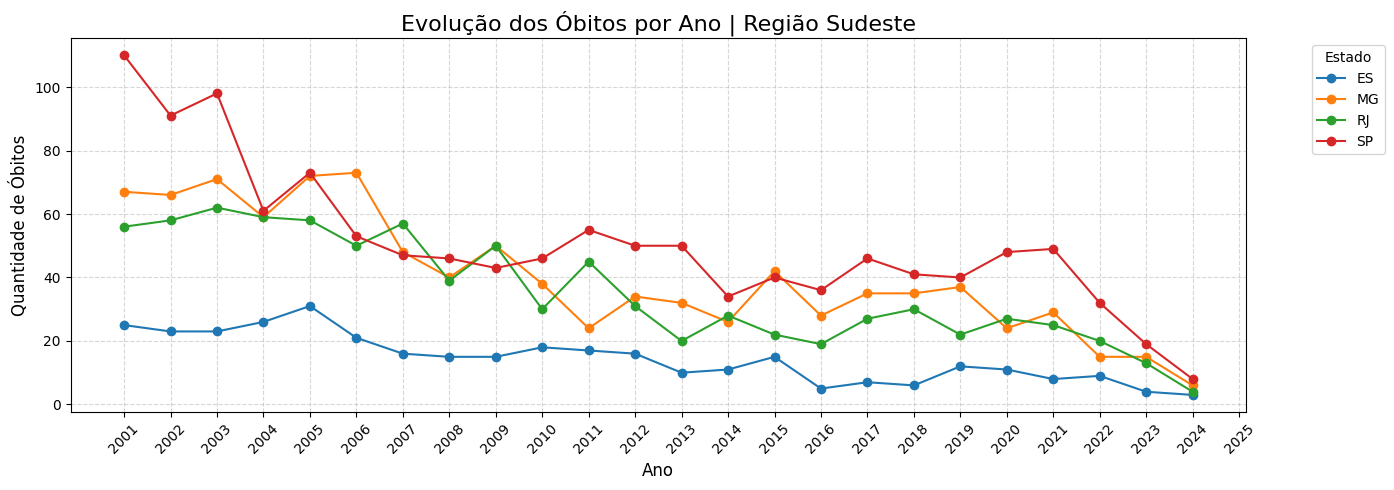

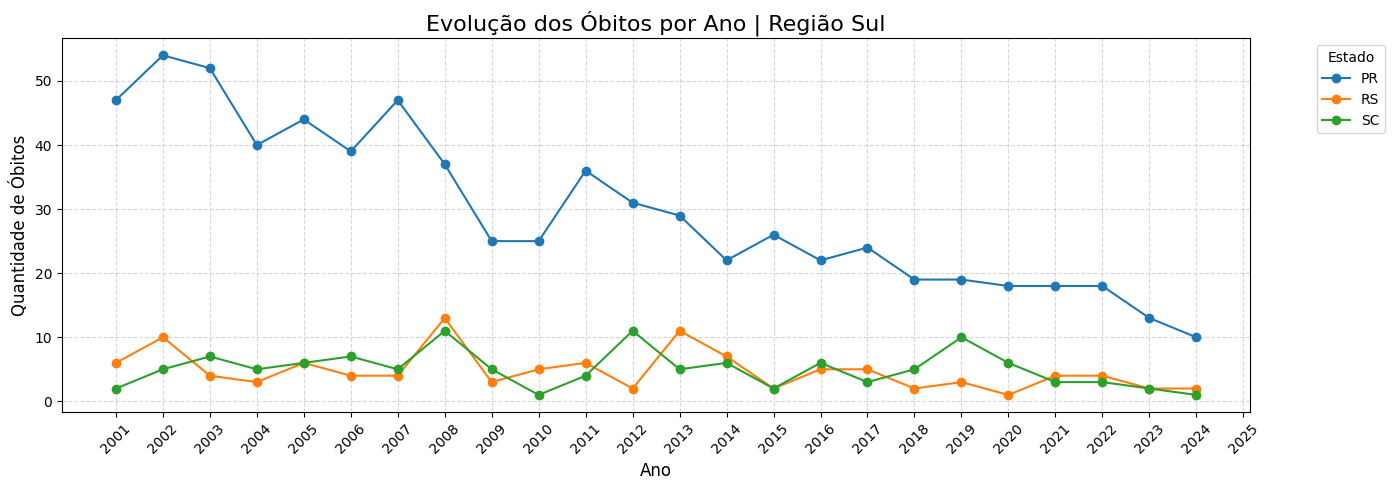

In [16]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 6)
df_obitos = df_dados[df_dados['TPALTA_N'] == '6'].copy()

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região para óbitos
dados_agrupados_obitos = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade_obitos')

# Obter lista única de regiões
regioes = dados_agrupados_obitos['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 5))

    dados_regiao = dados_agrupados_obitos[dados_agrupados_obitos['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade_obitos'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução dos Óbitos por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Óbitos', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados_obitos['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

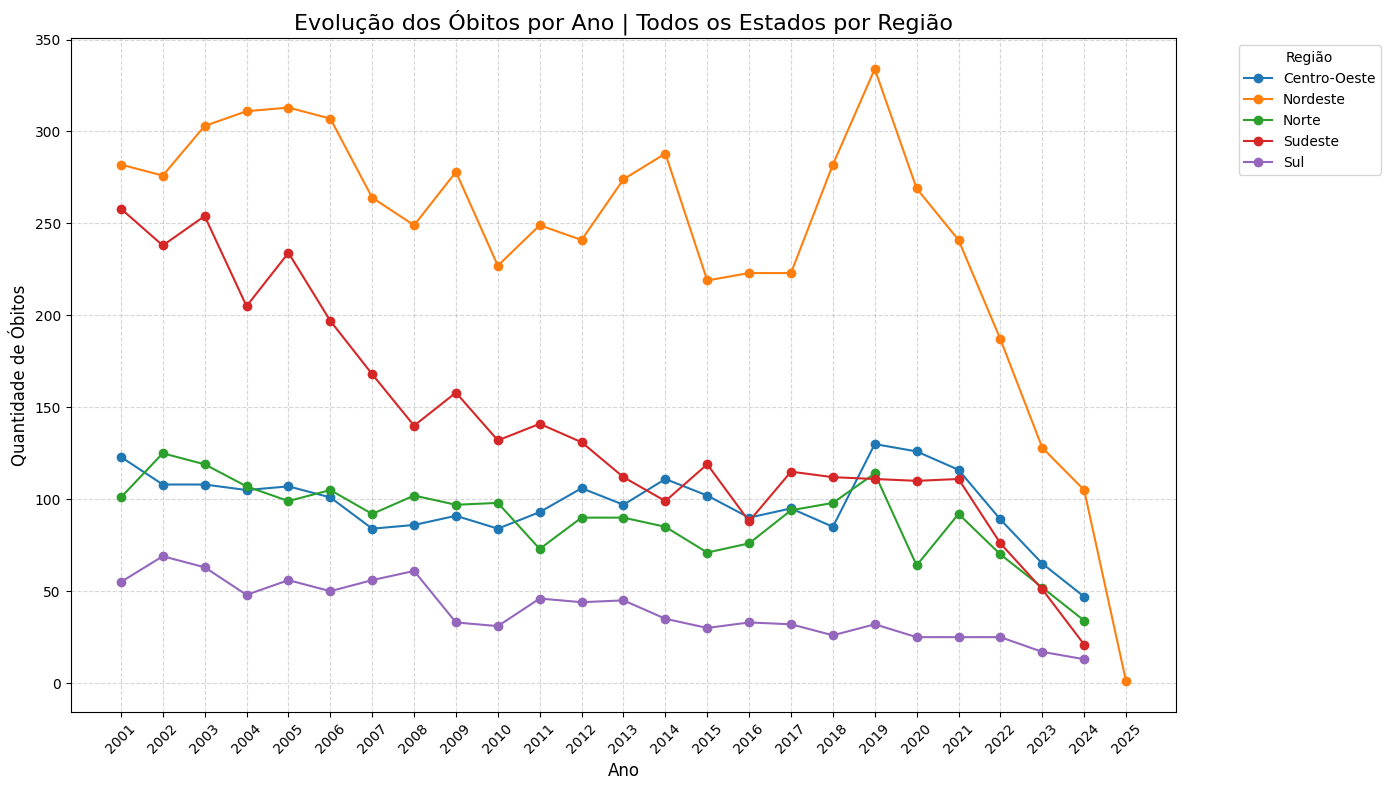

In [17]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 6)
df_obitos = df_dados[df_dados['TPALTA_N'] == '6'].copy()

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região para óbitos
dados_agrupados_obitos = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade_obitos')

# Obter lista única de regiões
regioes = dados_agrupados_obitos['regiao'].unique()

# Criar gráfico de linha para cada região, com a soma dos óbitos por ano
fig, ax = plt.subplots(figsize=(14, 8))

# Para cada região, plotar os dados de óbitos
for regiao in regioes:
    dados_regiao = dados_agrupados_obitos[dados_agrupados_obitos['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade_obitos'],
        marker='o',
        label=regiao
    )

# Configurar título e rótulos
ax.set_title('Evolução dos Óbitos por Ano | Todos os Estados por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Óbitos', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_obitos['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico para as regiões
plt.show()


## Associação com dados IBGE

In [18]:
# Carregar os dados IBGE (SIDRA)
path_dados_ibge = os.path.join('.', 'data', 'IBGE','populacao_municipios.csv')
dados_ibge = pd.read_csv(path_dados_ibge)

In [19]:
dados_ibge.info()
dados_ibge.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150950 entries, 0 to 150949
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ano             150950 non-null  int64 
 1   id_municipio    150950 non-null  int64 
 2   nome_municipio  150950 non-null  object
 3   sigla_uf        150950 non-null  object
 4   pessoas         150950 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.8+ MB


,ano,id_municipio,nome_municipio,sigla_uf,pessoas
0,1970,1100106,Guajará-Mirim,RO,27016
1,1970,1100205,Porto Velho,RO,84048
2,1970,1200104,Brasiléia,AC,12311
3,1970,1200203,Cruzeiro do Sul,AC,43584
4,1970,1200302,Feijó,AC,15768


### Agrupar por ano e somar o número de pessoas

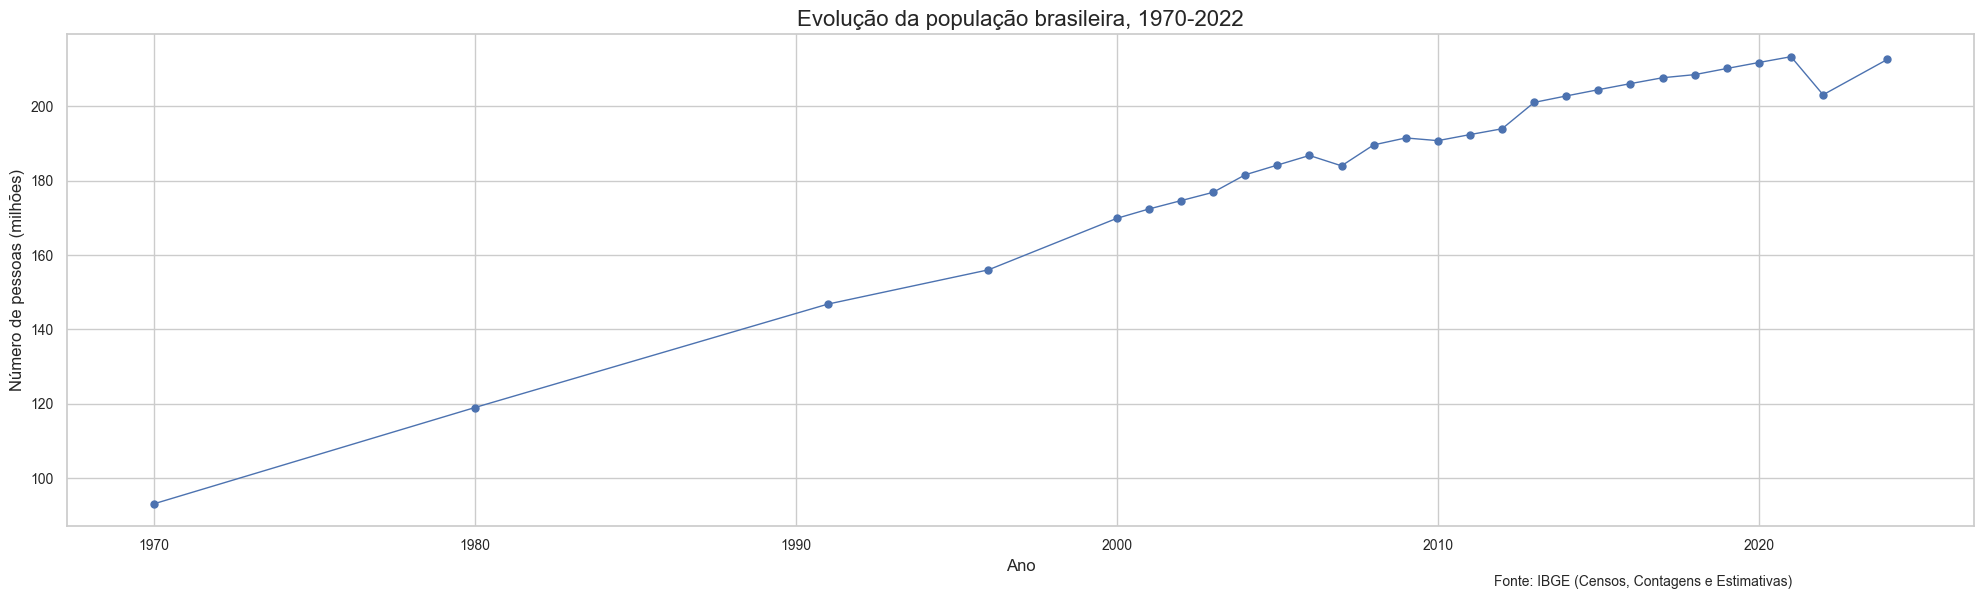

In [25]:

# Agrupar por ano e somar o número de pessoas
dados_agrupados = (
    dados_ibge.groupby("ano", as_index=False)
    .agg(n_pessoas=("pessoas", "sum"))
)

# Configurar o estilo do gráfico
sns.set_theme(style="whitegrid")

# Criar o gráfico
plt.figure(figsize=(20, 6))
plt.plot(dados_agrupados["ano"], dados_agrupados["n_pessoas"] / 1_000_000, 
         linewidth=1, marker="o", markersize=5)

# Personalizar o gráfico
plt.title("Evolução da população brasileira, 1970-2022", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de pessoas (milhões)", fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))  # Formatar os números no eixo Y
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.figtext(0.9, 0.01, "Fonte: IBGE (Censos, Contagens e Estimativas)", fontsize=10, ha="right")

# Exibir o gráfico
plt.tight_layout()
plt.show()


### por ano e por estado

In [26]:
# Filtrar os dados para considerar apenas óbitos (TPALTA_N == 6)
df_obitos = df_dados[df_dados['TPALTA_N'] == '6'].copy()

# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_obitos.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar os dados de população por ano e estado
df_populacao_estado_ano = dados_ibge.groupby(['ano', 'sigla_uf'])['pessoas'].sum().reset_index()

# Renomear a coluna 'sigla_uf' para 'sigla' para facilitar o merge
df_populacao_estado_ano.rename(columns={'sigla_uf': 'sigla'}, inplace=True)

# Agrupar os dados de óbitos por ano e estado
df_obitos_agrupados = df_dados_estado.groupby(['NU_ANO', 'sigla']).size().reset_index(name='total_obitos')

# Fazer o merge dos dados de óbitos agrupados com os dados de população por ano e estado
df_obitos_populacao_ano = df_obitos_agrupados.merge(
    df_populacao_estado_ano,
    left_on=['NU_ANO', 'sigla'],
    right_on=['ano', 'sigla'],
    how='left'
)

# Calcular a taxa de mortalidade por 100.000 habitantes (opcional)
df_obitos_populacao_ano['taxa_mortalidade'] = (df_obitos_populacao_ano['total_obitos'] / df_obitos_populacao_ano['pessoas']) * 100000

# Exibir o DataFrame resultante
print(df_obitos_populacao_ano)

     NU_ANO sigla  total_obitos     ano     pessoas  taxa_mortalidade
0      2001    AC             3  2001.0    574355.0          0.522325
1      2001    AL             6  2001.0   2856629.0          0.210038
2      2001    AM            18  2001.0   2900240.0          0.620638
3      2001    BA            37  2001.0  13214114.0          0.280004
4      2001    CE            65  2001.0   7547620.0          0.861199
..      ...   ...           ...     ...         ...               ...
628    2024    SC             1  2024.0   8058441.0          0.012409
629    2024    SE             5  2024.0   2291077.0          0.218238
630    2024    SP             8  2024.0  45973194.0          0.017401
631    2024    TO             6  2024.0   1577342.0          0.380387
632    2025    SE             1     NaN         NaN               NaN

[633 rows x 6 columns]


### Preencher dados faltantes de população utilizando interpolação

In [27]:

# Supondo que você já tenha os DataFrames df_obitos_estado_populacao e df_estados
# df_obitos_estado_populacao contém as colunas: NU_ANO, sigla, total_obitos, pessoas
# df_estados contém as colunas: sigla, regiao

# Preencher dados faltantes de população utilizando interpolação
df_obitos_estado_populacao_interpolado = df_obitos_populacao_ano.copy()

# Interpolação linear para preencher os valores de 'pessoas' nulos
df_obitos_estado_populacao_interpolado['pessoas'] = df_obitos_estado_populacao_interpolado.groupby('sigla')['pessoas'].transform(
    lambda x: x.interpolate(method='linear')
)

# Filtrar os dados válidos após interpolação
df_obitos_estado_populacao_interpolado_validos = df_obitos_estado_populacao_interpolado.dropna(subset=['pessoas'])

# Calcular a taxa de óbitos após interpolação
df_obitos_estado_populacao_interpolado_validos['taxa_obitos_100k'] = (
    df_obitos_estado_populacao_interpolado_validos['total_obitos'] / df_obitos_estado_populacao_interpolado_validos['pessoas']
) * 100000

# Adicionar a região ao DataFrame
df_obitos_estado_populacao_interpolado_validos = df_obitos_estado_populacao_interpolado_validos.merge(
    df_estados[['sigla', 'regiao']],  # Supondo que você tenha a coluna 'regiao'
    on='sigla',
    how='left'
)

# Verificar o DataFrame final após interpolação
print(df_obitos_estado_populacao_interpolado_validos.head())



   NU_ANO sigla  total_obitos     ano     pessoas  taxa_mortalidade  \
0    2001    AC             3  2001.0    574355.0          0.522325   
1    2001    AL             6  2001.0   2856629.0          0.210038   
2    2001    AM            18  2001.0   2900240.0          0.620638   
3    2001    BA            37  2001.0  13214114.0          0.280004   
4    2001    CE            65  2001.0   7547620.0          0.861199   

   taxa_obitos_100k    regiao  
0          0.522325     Norte  
1          0.210038  Nordeste  
2          0.620638     Norte  
3          0.280004  Nordeste  
4          0.861199  Nordeste  


### Obter lista única de regiões

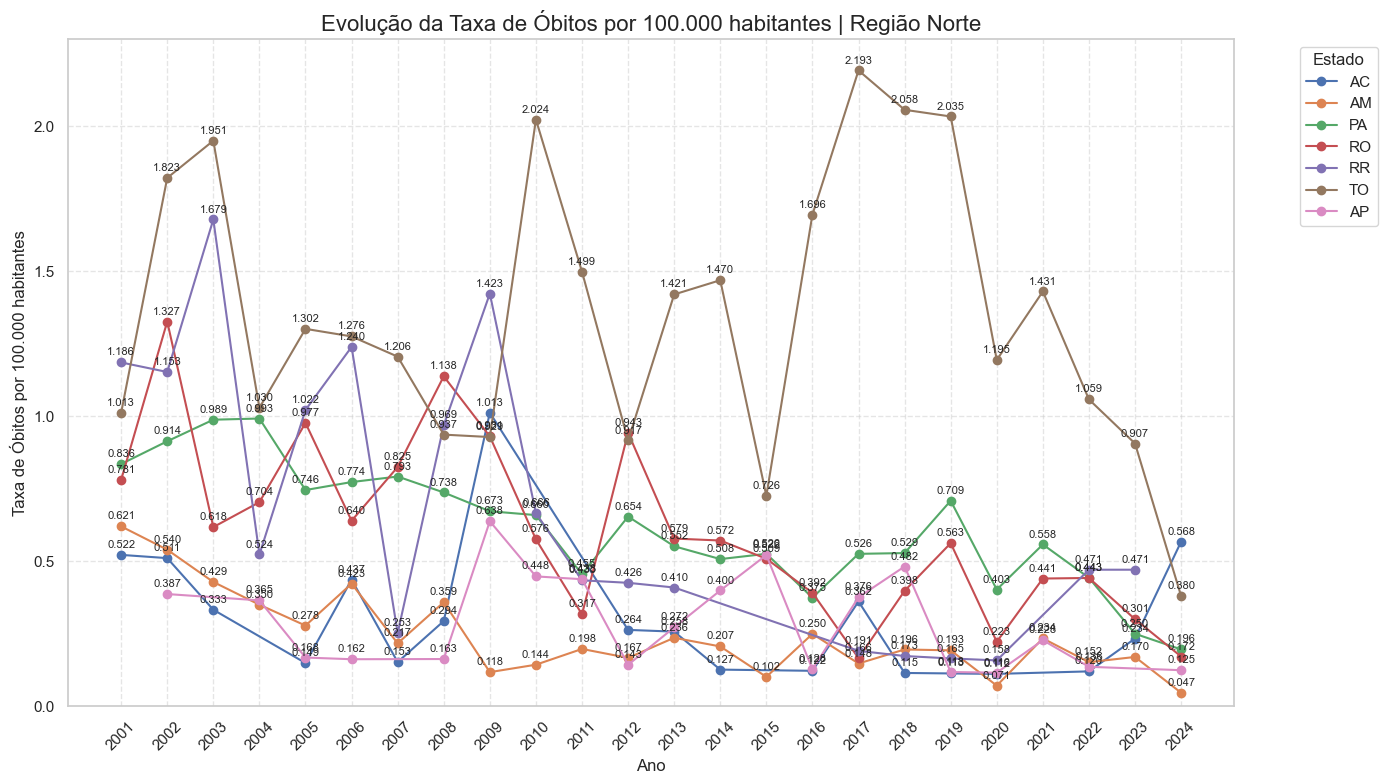

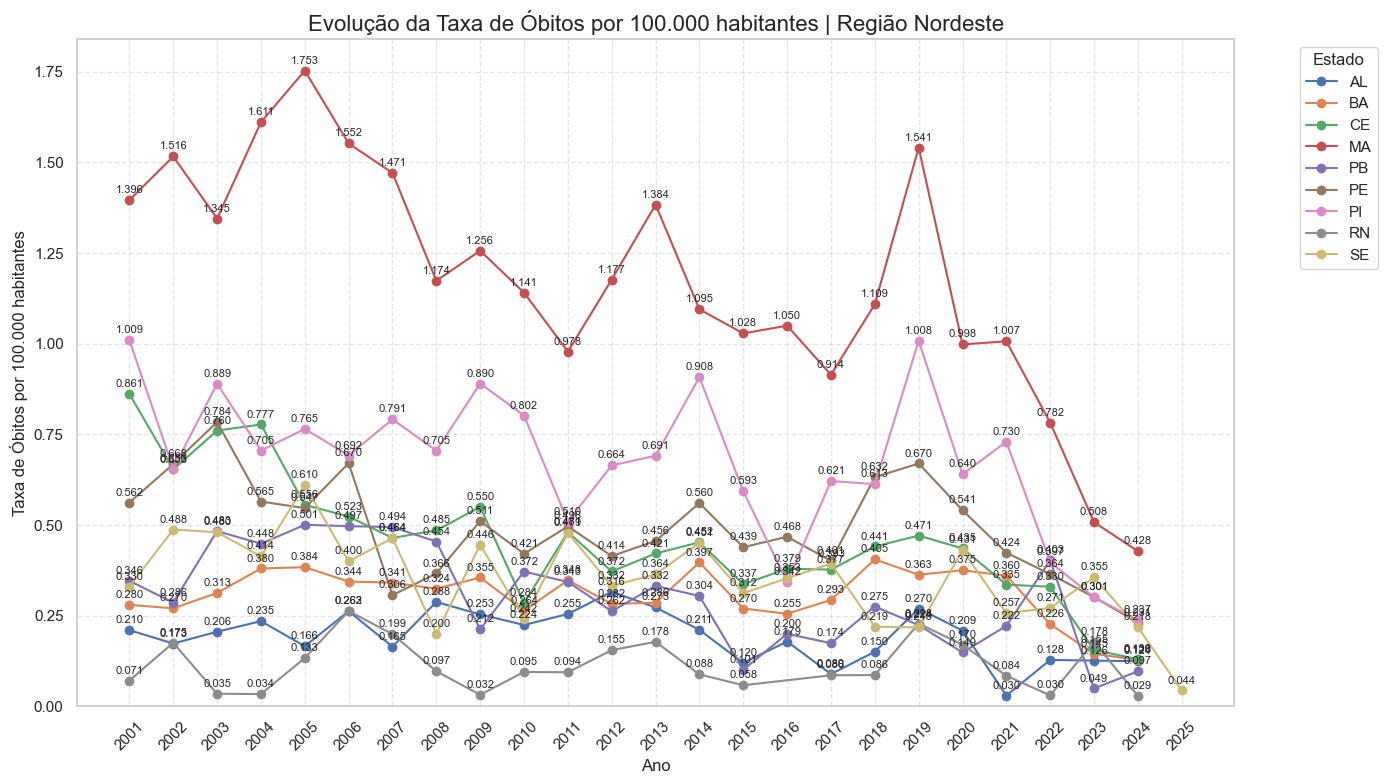

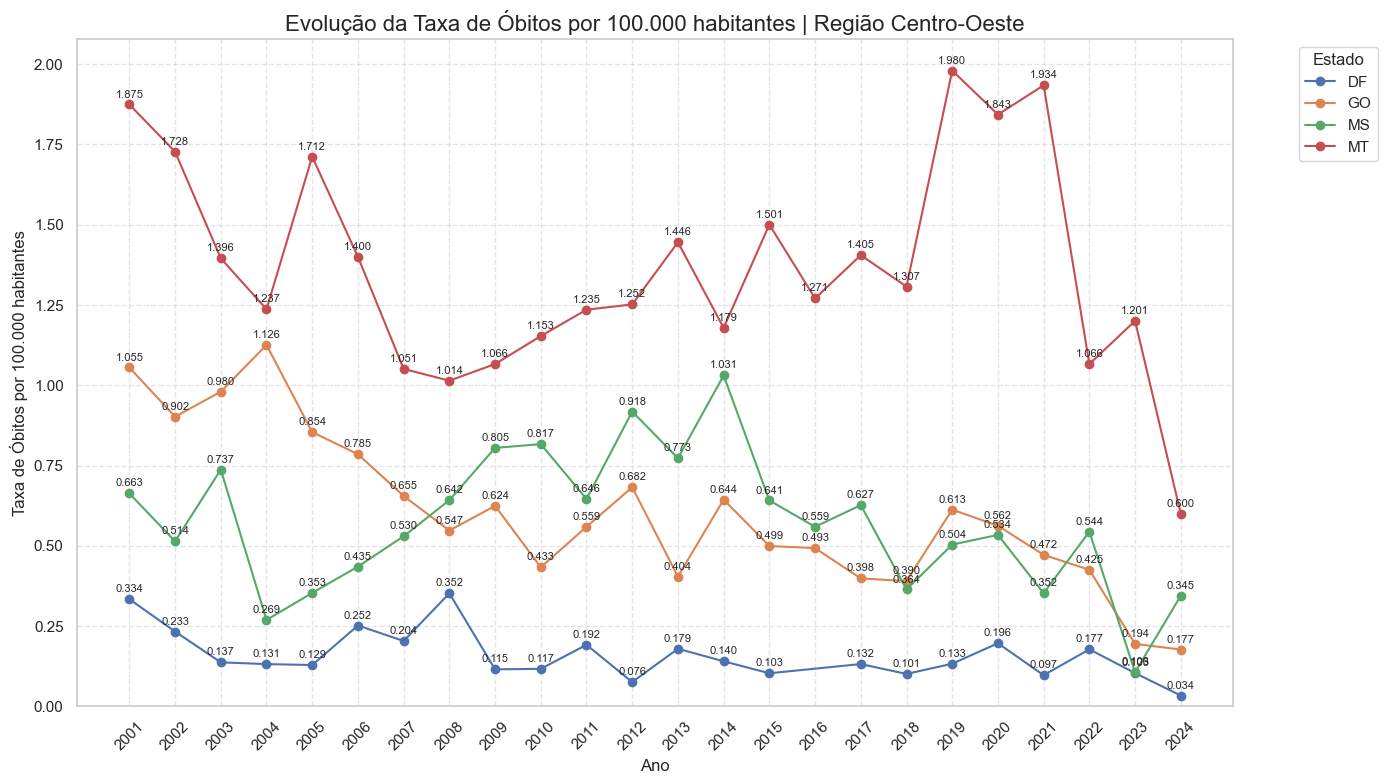

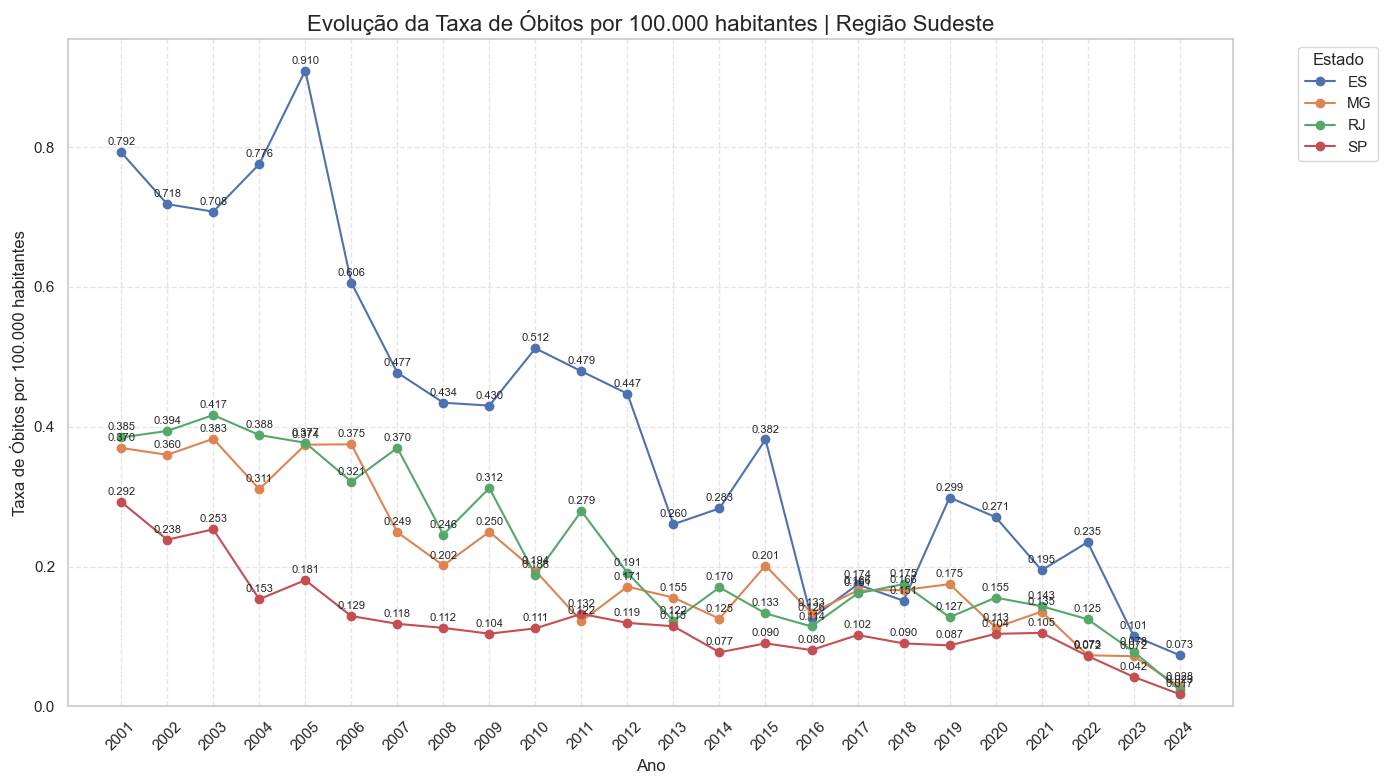

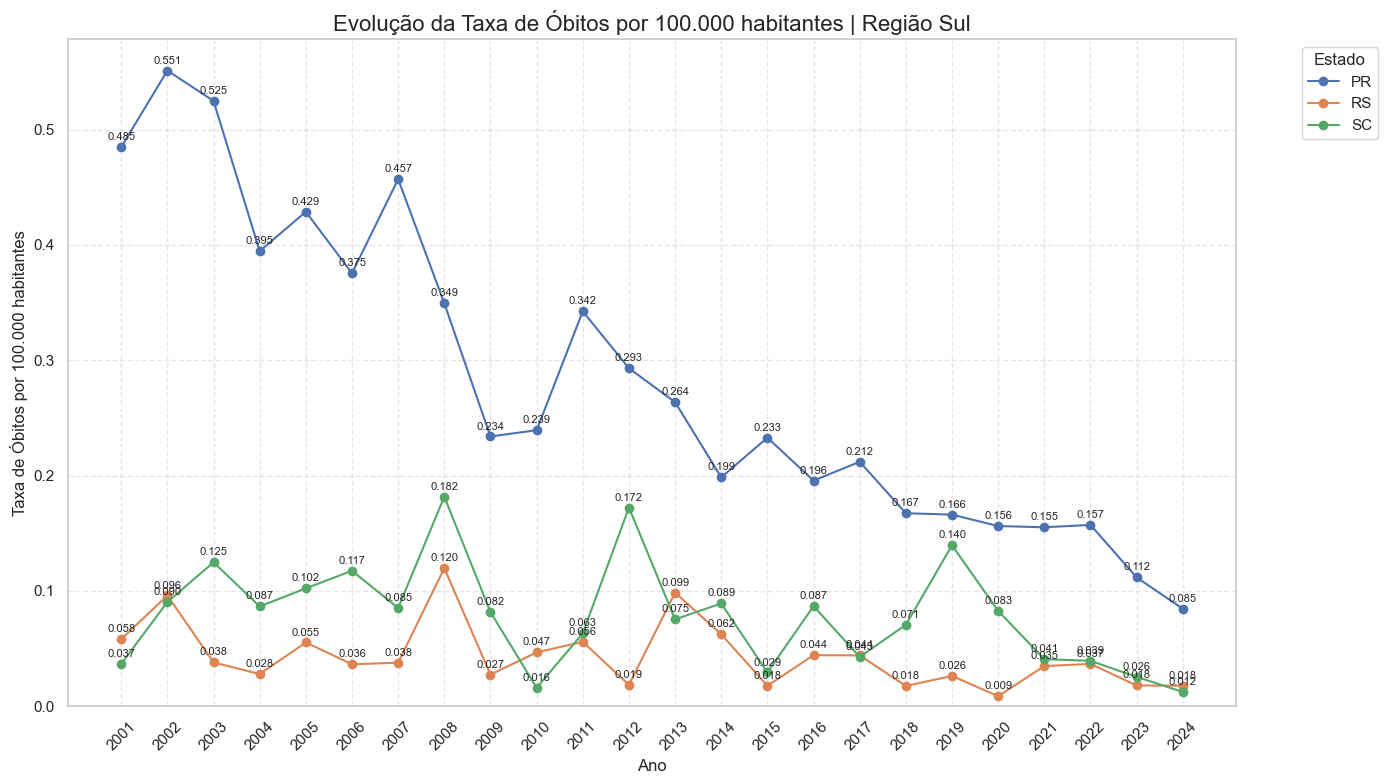

In [28]:
# Obter lista única de regiões
regioes = df_obitos_estado_populacao_interpolado_validos['regiao'].unique()

# Gerar um gráfico para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Filtrar dados da região atual
    dados_regiao = df_obitos_estado_populacao_interpolado_validos[df_obitos_estado_populacao_interpolado_validos['regiao'] == regiao]
    
    # Garantir que dados não nulos sejam considerados para a taxa de óbitos
    dados_regiao = dados_regiao.dropna(subset=['taxa_obitos_100k'])
    
    # Plotar a taxa de óbitos por estado dentro da região
    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        
        # Plotar a taxa de óbitos por 100.000 habitantes para cada estado
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['taxa_obitos_100k'],
            marker='o',
            label=estado
        )
    
    # Configurar títulos e rótulos
    ax.set_title(f'Evolução da Taxa de Óbitos por 100.000 habitantes | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Taxa de Óbitos por 100.000 habitantes', fontsize=12)
    
    # Adicionar valores nos pontos do gráfico, ajustando a posição para evitar sobreposição
    for _, row in dados_regiao.iterrows():
        ax.annotate(f'{row["taxa_obitos_100k"]:.3f}', 
                    (row['NU_ANO'], row['taxa_obitos_100k']),
                    textcoords="offset points",
                    xytext=(0, 5),
                    ha='center',
                    fontsize=8)
    
    # Melhorar a visualização
    plt.xticks(dados_regiao['NU_ANO'].unique(), rotation=45)
    ax.set_ylim(bottom=0)  # Garantir que o eixo Y comece de 0
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustar layout
    plt.tight_layout()

    # Exibir o gráfico
    plt.show()
